In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df=pd.read_csv(r"C:\Users\PRATHEEK POOJARY\OneDrive\Desktop\Machine Learning\datasets\housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [4]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [11]:
for col in df:
    print(f"{col} :{df[col].values}")

Avg. Area Income :[79545.45857432 79248.64245483 61287.06717866 ... 63390.6868855
 68001.33123509 65510.58180367]
Avg. Area House Age :[5.68286132 6.00289981 5.86588984 ... 7.25059061 5.53438842 5.99230531]
Avg. Area Number of Rooms :[7.00918814 6.73082102 8.51272743 ... 4.80508098 7.13014386 6.7923361 ]
Avg. Area Number of Bedrooms :[4.09 3.09 5.13 ... 2.13 5.44 4.07]
Area Population :[23086.80050269 40173.07217364 36882.1593997  ... 33266.14548965
 42625.62015585 46501.28380314]
Price :[1059033.55787012 1505890.91484695 1058987.98787608 ... 1030729.58315229
 1198656.87240769 1298950.48026696]
Address :['208 Michael Ferry Apt. 674\nLaurabury, NE 37010-5101'
 '188 Johnson Views Suite 079\nLake Kathleen, CA 48958'
 '9127 Elizabeth Stravenue\nDanieltown, WI 06482-3489' ...
 '4215 Tracy Garden Suite 076\nJoshualand, VA 01707-9165'
 'USS Wallace\nFPO AE 73316'
 '37778 George Ridges Apt. 509\nEast Holly, NV 29290-3595']


In [12]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [13]:
df['Avg. Area Income'].unique()

array([79545.45857432, 79248.64245483, 61287.06717866, ...,
       63390.6868855 , 68001.33123509, 65510.58180367])

In [14]:
# Features and target
X = df[['Avg. Area House Age', 'Avg. Area Number of Rooms','Avg. Area Number of Bedrooms']]
y = df["Price"]
 
x_train, x_test, y_train, y_test=train_test_split(X, y, test_size=0.20, random_state=42)

In [15]:
scaler = MinMaxScaler()
X_train_scl = scaler.fit_transform(x_train)
x_test_scl= scaler.transform(x_test)
  

In [17]:
model=LinearRegression(fit_intercept=True)
model.fit(X_train_scl, y_train)

LinearRegression()

In [19]:
model.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [20]:
y_pred=model.predict(x_test_scl)

In [21]:
model.coef_

array([1103470.57596398,  806025.23394325,   28810.58277108])

In [22]:
model.intercept_      # y=m(coef)*X + b(intercept)

257336.17798258248

In [25]:
X_train_scl[3]

array([0.49790651, 0.56443296, 0.23333333])

In [26]:
y_train[3]

1260616.8066294468

In [27]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 81281121831.11
R² Score: 0.34


[]

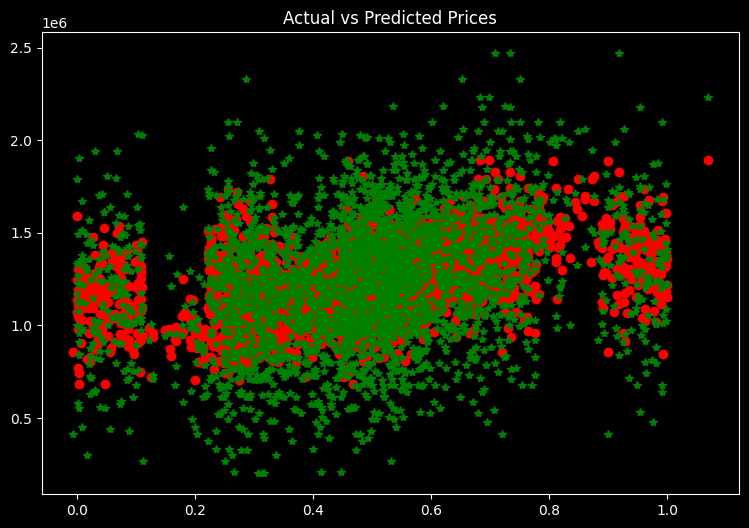

In [28]:
plt.figure(figsize=(9,6))
plt.plot(x_test_scl, y_pred, 'ro')
plt.plot(x_test_scl,y_test,'g*')
plt.title("Actual vs Predicted Prices")
plt.plot()


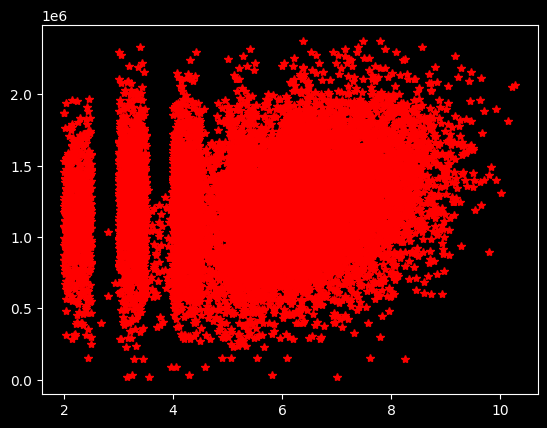

In [29]:
plt.plot(x_train, y_train, 'r*')

In [30]:
model.score(X_train_scl,y_train)

0.3156051173402138

In [31]:
model.score(x_test_scl,y_test)

0.3393521840063304